In [ ]:
import matplotlib.pyplot as plt 
import os 
os.chdir('../')
import torch
import numpy as np
import torch.nn as nn
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt
import random 
from decimal import Decimal
import deepwave
import warnings
from torchaudio.functional import biquad
from scipy.signal import butter
from torch.utils.tensorboard import SummaryWriter
import torch.nn.functional as F
from functools import partial
import time
from tools.utils import ComputeSNR,ComputeSSIM,ComputeRE
warnings.filterwarnings('ignore')
import os
from tools.regularization import*
from tools.tools import *
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [2]:
gpu_count = torch.cuda.device_count()
print(f"The number of available GPUs is: {gpu_count}")
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")  
    print(f"The selected GPU device is: {torch.cuda.get_device_name(DEVICE)}")
else:
    DEVICE = torch.device("cpu")
    print("No available GPUs detected, switched to using CPU")

The number of available GPUs is: 1
The selected GPU device is: NVIDIA GeForce RTX 4090


vp_true max min tensor(4790., device='cuda:0') tensor(1473.4270, device='cuda:0')


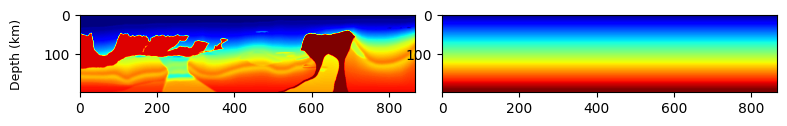

max values: tensor(4790., device='cuda:0')
min values: tensor(1473.4270, device='cuda:0')


In [3]:
### load vp_true and linear initial model
vp_true    = torch.tensor(np.load('./model_data/vp_truex200x868.npy')).to(DEVICE)
vp_initial =  torch.tensor(np.load('./model_data/vp_initx200x868.npy')).to(DEVICE)

dx, dz = 25,25 ## m

### show true and initial
print("vp_true max min",vp_true.max(),vp_true.min())

fig, ax = plt.subplots(1, 2, figsize=(9, 6))
fig1 = ax[0].imshow(vp_true.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vp_initial.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()
print("max values:",vp_true.max())
print("min values:",vp_true.min())

In [4]:

# --------------------------
# Frequency Testing Parameters
# --------------------------
test_low_fre = 'yes'    # Enable low-frequency testing ('yes'/'no')
cutoff_fre = 1.0      # Cutoff frequency for filtering (Hz)
corners = 16.0          # Filter corners/order for frequency testing

# --------------------------
# Noise Testing Parameters  
# --------------------------
test_low_noise = 'yes'  # Enable noise testing ('yes'/'no')
noise_level = 5      # Standard deviation of Gaussian noise to add

# --------------------------
#  forward parameters
# --------------------------
DT = 0.008                                              
F_PEAK = 6.0                                            
DH = dx                                                  
N_SHOTS = 60                                             
N_SOURCE_PER_SHOT = 1
model_shape = [vp_true.shape[0],vp_true.shape[1]]
NT = 2000

inpa = {
    'ns': N_SHOTS,               # Number of shots
    'nr': 852,
    'dh': dx,                    # Spatial sampling (m)
    'dt': DT,                    # Time sampling (s)
    'nt': NT,                      # Recording duration (s)
    'accuracy': 4,
    'pml_width': [20, 20, 20, 20]
}


In [5]:
### source or receiver positions
src_loc, rec_loc = setup_acquisition_geometry_comstom(
    inpa=inpa,
    model_shape=model_shape,
    N_SHOTS=N_SHOTS,
    N_SOURCE_PER_SHOT=N_SOURCE_PER_SHOT,
    DEVICE=DEVICE,
    src_margin=8,  # Sources 13 grid points from edges
    src_depth=2,    # Sources at ~40m depth (2 * 20m)
    rec_margin=8,  # Receivers 13 grid points from edges
    rec_depth=17    # Receivers at ~340m depth (17 * 20m)
)
print('Receiver location tensor shape:', rec_loc.shape)
print('Source location tensor shape:', src_loc.shape)

#### source wavelet
src = generate_source_wavelets(
    F_PEAK=F_PEAK,
    NT=NT,
    DT=DT,
    N_SHOTS=N_SHOTS,
    N_SOURCE_PER_SHOT=N_SOURCE_PER_SHOT,
    DEVICE=DEVICE,
    test_low_fre=test_low_fre,  # Enable filtering
    cutoff_fre=cutoff_fre,
    corners=corners
)
src_rec_loc_path = './src_rec_loc/'
if not os.path.exists(src_rec_loc_path):
    os.makedirs(src_rec_loc_path)
np.save(src_rec_loc_path + "src_loc.npy", src_loc.detach().cpu().numpy())
np.save(src_rec_loc_path + "rec_loc.npy", rec_loc.detach().cpu().numpy())

source_path = './source/'
if not os.path.exists(source_path):
    os.makedirs(source_path)
np.save(source_path + "src.npy", src.detach().cpu().numpy())

print(src.shape)

Model dimensions: 21700.0m (width) x 5000.0m (depth)
Acquisition geometry configured:
- Sources: 60x1 at ~50m depth
- Receivers: 852 channels at ~425m depth
- Source locations shape: (60, 1, 2)
- Receiver locations shape: (60, 852, 2)
Receiver location tensor shape: torch.Size([60, 852, 2])
Source location tensor shape: torch.Size([60, 1, 2])
Generated 60x1 source wavelets:
- Peak frequency: 6.0Hz
- Duration: 16.000s (2000 samples)
- Applied 16.0-corner highpass at 1.0Hz
torch.Size([60, 1, 2000])


Added Gaussian noise (snr=5)
Generated synthetic data shape: (60, 2000, 852) (shots×receivers×time)


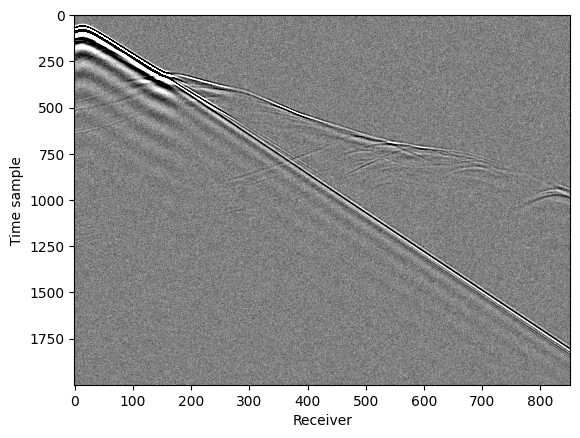

In [6]:
Physics=Physics_deepwave
# Run simulation
d_obs = run_forward_simulation(
    Physics=Physics_deepwave,
    vp_true=vp_true,
    inpa=inpa,
    src=src,
    src_loc=src_loc,
    rec_loc=rec_loc,
    test_low_noise=test_low_noise,
    noise_level=noise_level,
    device=DEVICE
)
d_obs = d_obs.squeeze()

vmin, vmax = torch.quantile(d_obs[1],
                            torch.tensor([0.01, 0.99]).to(DEVICE))
plt.figure()
plt.imshow(d_obs[1].cpu(), aspect='auto', cmap='gray',
            vmin=vmin, vmax=vmax)
plt.xlabel("Receiver")
plt.ylabel("Time sample")

obs_data_path = './obs_data/'
if not os.path.exists(obs_data_path):
    os.makedirs(obs_data_path)
np.save(obs_data_path + "d_obs.npy", d_obs.detach().cpu().numpy())

